{'weight_kg': 65.0, 'height_m': 1.52, 'bmi': 28.13, 'bmi_type': 'normal'}


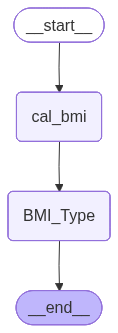

In [13]:
# Sequential workflows 
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


class BMIState(TypedDict):
    weight_kg: float
    height_m:float
    bmi:float
    bmi_type:str

def calculate_bmi(state: BMIState)-> BMIState:
    weight= state["weight_kg"]
    height= state["height_m"]
    bmi = weight/(height**2)

    state["bmi"] = round(bmi,2)
    return state

def bmi_type(state:BMIState) -> BMIState:
    bmi=state["bmi"]
    if bmi<25:
        state["bmi_type"] = "low"
        return state
    elif 25<bmi<34:
        state["bmi_type"]="normal"
        return state
    else:
        state["bmi_type"]="obese"
        return state  




graph = StateGraph(BMIState)
# add nodes to your graph
graph.add_node("cal_bmi",calculate_bmi)
graph.add_node("BMI_Type",bmi_type)
# add edges to your graph
graph.add_edge(START,"cal_bmi")
graph.add_edge("cal_bmi","BMI_Type")
graph.add_edge("BMI_Type",END)

# compile the graph
app = graph.compile()
wt=float(input("Enter the weight in kg"))
ht=float(input("Enter the height in m"))
result=app.invoke({'weight_kg':wt,"height_m":ht})
print(result)
app

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\n                Strike rate = 200.0\n                Balls per boundary = 5.0\n                Boundary percent = 48.0                \n'}


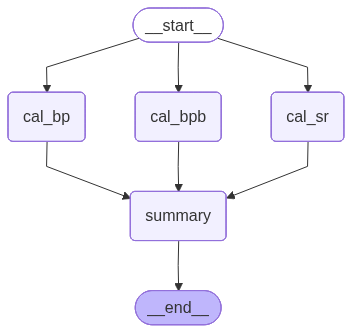

In [10]:
# parallel workflow

#Non LLM Workflow

from langgraph.graph import StateGraph,START,END
from typing import TypedDict

class BatsmanState(TypedDict):
    #inputs
    runs: int
    balls:int
    fours:int
    sixes: int 

    sr: float # strike rate
    bpb: float # balls per boundary
    boundary_percent: float 
    summary:str

def calculate_sr(state:BatsmanState):
    sr=(state["runs"]/state["balls"])*100
    
    return {"sr":sr} # while handling the parallel nodes working never return entire state it gets parallel update issue.

def cal_bpb(state:BatsmanState):

    bpb=state["balls"]/(state["fours"]+state["sixes"])
    
    return {"bpb":bpb}
def cal_boundary_percent(state:BatsmanState):
    bp = (((state["fours"]*4)+(state["sixes"]*6))/state["runs"])*100
    
    return {"boundary_percent":bp}

def summary(state:BatsmanState):
    summary = f"""
                Strike rate = {state["sr"]}
                Balls per boundary = {state["bpb"]}
                Boundary percent = {state["boundary_percent"]}                
"""
    
    return {"summary":summary}

graph = StateGraph(BatsmanState)

# nodes
graph.add_node("cal_sr",calculate_sr)
graph.add_node("cal_bpb",cal_bpb)
graph.add_node("cal_bp",cal_boundary_percent)
graph.add_node("summary",summary)

# edges
graph.add_edge(START,"cal_sr")
graph.add_edge(START,"cal_bpb")
graph.add_edge(START,"cal_bp")

graph.add_edge("cal_sr","summary")
graph.add_edge("cal_bpb","summary")
graph.add_edge("cal_bp","summary")

graph.add_edge("summary",END)

app = graph.compile()
initial_state={
    "runs":100,
    "balls":50,
    "fours":6,
    "sixes":4
}

print(app.invoke(initial_state))

app


To read your Hugging Face token safely from a .env file, you need to use the python-dotenv package. This keeps your API key secure and prevents it from being hardcoded into your scripts.
Here is the step-by-step setup guide.
------------------------------
## Step 1: Install the Environment Library
Install the library required to read .env files, along with the LangChain components:

pip install python-dotenv langchain-huggingface langchain-core huggingface_hub

## Step 2: Create Your .env File
In the exact same folder where your Python script lives, create a new file named exactly .env (with the dot at the beginning, no extension). Add your token inside it:

HUGGINGFACEHUB_API_TOKEN=hf_your_actual_token_goes_here

------------------------------
## Step 3: Run the Code
The load_dotenv() function automatically finds your .env file and loads the token into your system environment variables. The Hugging Face libraries will automatically detect and use it.

import os
from dotenv import load_dotenvfrom langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import HumanMessage, SystemMessage

-1. Load environment variables from the .env file
load_dotenv()
- Verify the token loaded successfully (optional safety check)
if not os.getenv("HUGGINGFACEHUB_API_TOKEN"):
    raise ValueError("HUGGINGFACEHUB_API_TOKEN is missing! Check your .env file.")
- 2. Set up your model endpoint# The library automatically reads HUGGINGFACEHUB_API_TOKEN from the environment

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7,
)
- 3. Wrap with ChatHuggingFace for structured conversations
chat_model = ChatHuggingFace(llm=llm)
- 4. Create and send your chat message

messages = [
    SystemMessage(content="You are a polite assistant."),
    HumanMessage(content="Tell me a joke about a computer programmer.")
]
response = chat_model.invoke(messages)
print(response.content)

------------------------------
## Pro-Tips for Production

* Git Security: If you use Git, add .env to your .gitignore file so you do not accidentally push your private Hugging Face token to public repositories like GitHub.
* Alternative Token Key: If your code specifically looks for a custom variable name like HF_TOKEN, you can load it manually using hf_token = os.getenv("HF_TOKEN") and pass it directly inside your endpoint using HuggingFaceEndpoint(..., huggingfacehub_api_token=hf_token).

If you run into any authentication errors, let me know:

* What error message are you seeing in the terminal?
* Are you trying to use a gated model (like Llama 3) that requires you to accept a license agreement on Hugging Face first?




In [ ]:
# upsc essay evaluation

# start--> clarity of thought
#      --> Depth of analysis
#      --> Language

# output: 1) text feedback
#         2) score (0-10)
#         3) summarized feedback  and final score

# Title : UPSC Essay Workflow

from langgraph.graph import StateGraph, START, END
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import HumanMessage, SystemMessage
load_dotenv()

# Verify the token loaded successfully (optional safety check)
if not os.getenv("HUGGINGFACEHUB_API_TOKEN"):
    raise ValueError("HUGGINGFACEHUB_API_TOKEN is missing! Check your .env file.")
# 2. Set up your model endpoint
# The library automatically reads HUGGINGFACEHUB_API_TOKEN from the environment
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    temperature=0)

model = ChatHuggingFace(llm=llm)


# response = model.invoke("Explain about the gen ai")

# print(response.content)



c:\Users\tarun\OneDrive\Desktop\Langchain_works\tasks\resume_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Generalized Artificial Intelligence (Gen AI)**

Generalized Artificial Intelligence (Gen AI) is a hypothetical AI system that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, similar to human intelligence. It is designed to be general-purpose, versatile, and capable of adapting to new situations, problems, and domains.

**Characteristics of Gen AI:**

1. **Universal Intelligence**: Gen AI has the ability to learn, reason, and apply its knowledge across various domains, including natural language processing (NLP), computer vision, decision-making, and problem-solving.
2. **Self-Improvement**: Gen AI can improve its own performance, learning rate, and adaptability through self-supervised learning, self-modification, and self-organization.
3. **Creativity and Innovation**: Gen AI has the capacity to generate novel and innovative solutions, ideas, and products, often surpassing human creativity.
4. **Human-Like Intelligence**: Gen AI simulates

In [13]:
# work starts here :
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import TypedDict,Annotated
import os
import operator
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser


test_essay="""
Generalized Artificial Intelligence (Gen AI)

Generalized Artificial Intelligence (Gen AI) is a hypothetical AI system that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, similar to human intelligence. It is designed to be general-purpose, versatile, and capable of adapting to new situations, problems, and domains.

Characteristics of Gen AI:

1. **Universal Intelligence**: Gen AI has the ability to learn, reason, and apply its knowledge across various domains, including natural language processing (NLP), computer vision, decision-making, and problem-solving.
2. **Self-Improvement**: Gen AI can improve its own performance, learning rate, and adaptability through self-supervised learning, self-modification, and self-organization.
3. **Creativity and Innovation**: Gen AI has the capacity to generate novel and innovative solutions, ideas, and products, often surpassing human creativity.
4. **Human-Like Intelligence**: Gen AI simulates human-like thought processes, memory, and decision-making capabilities, making it more relatable and effective in interactions with humans.
5. **Autonomy and Self-Organization**: Gen AI can operate independently, make decisions, and reorganize itself to adapt to changing circumstances and situations.

Types of Gen AI:

1. Artificial General Intelligence (AGI): AGI is a subset of Gen AI that focuses on creating a machine that can perform any intellectual task that a human can. AGI systems are designed to be general-purpose and adaptable.
2. Strong AI: Strong AI is a version of Gen AI that possesses human-like intelligence, reasoning, and cognitive abilities, often considered the ultimate goal in AI research.

Potential Applications of Gen AI:

1. Scientific Research: Gen AI can accelerate scientific discoveries, simulate complex phenomena, and analyze vast amounts of data to understand the world around us.
2. Healthcare and Medicine: Gen AI can assist in diagnosing diseases, developing personalized treatments, and streamlining clinical trials.
3. Education and Personalized Learning: Gen AI can create tailored learning experiences, adapt to individual learning styles, and provide real-time feedback.
4. Economic Growth and Development: Gen AI can optimize business operations, predict market trends, and create new opportunities for economic growth.

Challenges and Risks:

1. Job Displacement: Gen AI may replace human workers in various industries, leading to unemployment and social disruption.
2. Bias and Fairness: Gen AI
"""    


class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Detailed feedback for the essay")
    score:int=Field(description="score out of 10",ge=0,le=10)


load_dotenv()

# Verify the token loaded successfully (optional safety check)
if not os.getenv("HUGGINGFACEHUB_API_TOKEN"):
    raise ValueError("HUGGINGFACEHUB_API_TOKEN is missing! Check your .env file.")
# 2. Set up your model endpoint
# The library automatically reads HUGGINGFACEHUB_API_TOKEN from the environment
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    temperature=0,
    max_new_tokens=1024)

model = ChatHuggingFace(llm=llm)

prompt_template = ChatPromptTemplate.from_messages([
    ("system", (
        "You are an expert essay evaluator.\n"
        "Your task is to analyze the user's essay and output a valid JSON object matching the requested schema.\n"
        "CRITICAL: Do NOT copy the schema definition or properties object. Fill in the keys with actual values.\n"
        "CRITICAL: Output ONLY the raw JSON object. Do NOT include markdown blocks like ```json, headers, or conversational text.\n"
        "{format_instructions}"
    )),
    ("human", "Evaluate the following essay:\n\n{essay_content}")
])
parser = PydanticOutputParser(pydantic_object=EvaluationSchema)
chain = prompt_template | model | parser

response = chain.invoke({
        "essay_content": essay,
        "format_instructions": parser.get_format_instructions()
    })



class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores: Annotated[list[int],operator.add]   # operator.add is a reducer function
    avg_score:float

def evaluate_language(state:UPSCState):
    prompt = f"""Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"""
    output = chain.invoke(prompt)

    return {"language_feedback":output.feedback,"individual_scores":[output.score]}

def evaluate_analysis(state:UPSCState):
    prompt = f"""Evaluate the quality of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"""
    output = chain.invoke(prompt)

    return {"analysis_feedback":output.feedback,"individual_scores":[output.score]}

def evaluate_thought(state:UPSCState):
    prompt = f"""Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"""
    output = chain.invoke(prompt)

    return {"clarity_feedback":output.feedback ,"individual_scores":[output.score]}

def final_evaluation(state:UPSCState):
    # summary feedback
    prompt = f""" based on the follwing feedbacks \n language Feedback - {state['language_feedback']}\n depth of analysis feedback - {state['analysis_feedback']}\n clarity of thought feedback-{state['clarity_feedback']}"""
    overall_feedback = model.invoke(prompt).content
    # avg calculation
    avg_score = sum(state["individual_scores"])/len(state["individual_scores"])
    
    return {"overall_feedback":overall_feedback,"avg_score":avg_score} 

graph = StateGraph(UPSCState)

# nodes

graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node("final_evaluation",final_evaluation)


# edges 
graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_thought")

graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_analysis","final_evaluation")
graph.add_edge("evaluate_thought","final_evaluation")

graph.add_edge("final_evaluation",END)

workflow = graph.compile()



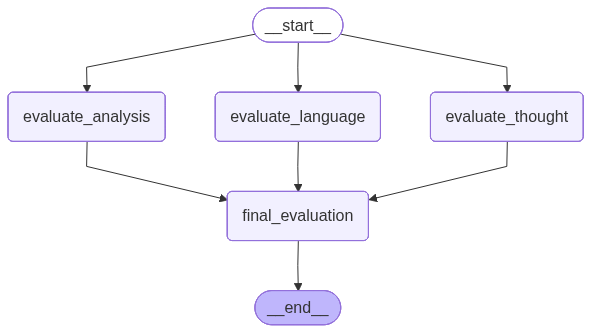

In [14]:
workflow

In [15]:
initial_state ={"essay":test_essay}
workflow.invoke(initial_state)

TypeError: Expected mapping type as input to ChatPromptTemplate. Received <class 'str'>.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/INVALID_PROMPT_INPUT 

In [17]:
# work starts here :
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import TypedDict,Annotated
import os
import operator
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser


test_essay="""
Generalized Artificial Intelligence (Gen AI)

Generalized Artificial Intelligence (Gen AI) is a hypothetical AI system that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, similar to human intelligence. It is designed to be general-purpose, versatile, and capable of adapting to new situations, problems, and domains.

Characteristics of Gen AI:

1. **Universal Intelligence**: Gen AI has the ability to learn, reason, and apply its knowledge across various domains, including natural language processing (NLP), computer vision, decision-making, and problem-solving.
2. **Self-Improvement**: Gen AI can improve its own performance, learning rate, and adaptability through self-supervised learning, self-modification, and self-organization.
3. **Creativity and Innovation**: Gen AI has the capacity to generate novel and innovative solutions, ideas, and products, often surpassing human creativity.
4. **Human-Like Intelligence**: Gen AI simulates human-like thought processes, memory, and decision-making capabilities, making it more relatable and effective in interactions with humans.
5. **Autonomy and Self-Organization**: Gen AI can operate independently, make decisions, and reorganize itself to adapt to changing circumstances and situations.

Types of Gen AI:

1. Artificial General Intelligence (AGI): AGI is a subset of Gen AI that focuses on creating a machine that can perform any intellectual task that a human can. AGI systems are designed to be general-purpose and adaptable.
2. Strong AI: Strong AI is a version of Gen AI that possesses human-like intelligence, reasoning, and cognitive abilities, often considered the ultimate goal in AI research.

Potential Applications of Gen AI:

1. Scientific Research: Gen AI can accelerate scientific discoveries, simulate complex phenomena, and analyze vast amounts of data to understand the world around us.
2. Healthcare and Medicine: Gen AI can assist in diagnosing diseases, developing personalized treatments, and streamlining clinical trials.
3. Education and Personalized Learning: Gen AI can create tailored learning experiences, adapt to individual learning styles, and provide real-time feedback.
4. Economic Growth and Development: Gen AI can optimize business operations, predict market trends, and create new opportunities for economic growth.

Challenges and Risks:

1. Job Displacement: Gen AI may replace human workers in various industries, leading to unemployment and social disruption.
2. Bias and Fairness: Gen AI
"""    


class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Detailed feedback for the essay")
    score:int=Field(description="score out of 10",ge=0,le=10)


load_dotenv()

# Verify the token loaded successfully (optional safety check)
if not os.getenv("HUGGINGFACEHUB_API_TOKEN"):
    raise ValueError("HUGGINGFACEHUB_API_TOKEN is missing! Check your .env file.")

# 2. Set up your model endpoint
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    temperature=0,
    max_new_tokens=1024)

model = ChatHuggingFace(llm=llm)

# Create a base prompt template that will be customized for each evaluation
base_prompt_template = ChatPromptTemplate.from_messages([
    ("system", (
        "You are an expert essay evaluator.\n"
        "Your task is to analyze the user's essay and output a valid JSON object matching the requested schema.\n"
        "CRITICAL: Do NOT copy the schema definition or properties object. Fill in the keys with actual values.\n"
        "CRITICAL: Output ONLY the raw JSON object. Do NOT include markdown blocks like ```json, headers, or conversational text.\n"
        "{format_instructions}\n\n"
        "Evaluation criteria: {criteria}"
    )),
    ("human", "{essay_content}")
])

parser = PydanticOutputParser(pydantic_object=EvaluationSchema)

# Create separate chains for each evaluation type
def create_evaluation_chain(criteria):
    prompt = base_prompt_template.partial(
        format_instructions=parser.get_format_instructions(),
        criteria=criteria
    )
    return prompt | model | parser

# Create chains for different evaluation criteria
language_chain = create_evaluation_chain("Evaluate language quality - grammar, vocabulary, sentence structure, and writing style")
analysis_chain = create_evaluation_chain("Evaluate depth of analysis - logical reasoning, argument development, and critical thinking")
clarity_chain = create_evaluation_chain("Evaluate clarity of thought - organization, coherence, and flow of ideas")

class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores: Annotated[list[int],operator.add]
    avg_score:float

def evaluate_language(state:UPSCState):
    # Pass dictionary with required keys
    output = language_chain.invoke({
        "essay_content": state['essay']
    })
    return {"language_feedback": output.feedback, "individual_scores": [output.score]}

def evaluate_analysis(state:UPSCState):
    output = analysis_chain.invoke({
        "essay_content": state['essay']
    })
    return {"analysis_feedback": output.feedback, "individual_scores": [output.score]}

def evaluate_clarity(state:UPSCState):  # Renamed from evaluate_thought to be more accurate
    output = clarity_chain.invoke({
        "essay_content": state['essay']
    })
    return {"clarity_feedback": output.feedback, "individual_scores": [output.score]}

def final_evaluation(state:UPSCState):
    # summary feedback
    prompt = f"""Based on the following feedbacks, provide an overall evaluation summary of the essay:

Language Feedback: {state['language_feedback']}
Depth of Analysis Feedback: {state['analysis_feedback']}
Clarity of Thought Feedback: {state['clarity_feedback']}

Provide a comprehensive overall assessment."""
    
    overall_feedback = model.invoke(prompt).content
    
    # avg calculation
    avg_score = sum(state["individual_scores"]) / len(state["individual_scores"])
    
    return {"overall_feedback": overall_feedback, "avg_score": avg_score} 

graph = StateGraph(UPSCState)

# nodes
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_clarity", evaluate_clarity)  # Updated name
graph.add_node("final_evaluation", final_evaluation)

# edges - all three evaluators run in parallel
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_clarity")

# After each evaluator completes, go to final_evaluation
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_clarity", "final_evaluation")

graph.add_edge("final_evaluation", END)

workflow = graph.compile()

# Test the workflow

initial_state = {"essay": test_essay}
workflow.invoke(initial_state)


{'essay': '\nGeneralized Artificial Intelligence (Gen AI)\n\nGeneralized Artificial Intelligence (Gen AI) is a hypothetical AI system that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, similar to human intelligence. It is designed to be general-purpose, versatile, and capable of adapting to new situations, problems, and domains.\n\nCharacteristics of Gen AI:\n\n1. **Universal Intelligence**: Gen AI has the ability to learn, reason, and apply its knowledge across various domains, including natural language processing (NLP), computer vision, decision-making, and problem-solving.\n2. **Self-Improvement**: Gen AI can improve its own performance, learning rate, and adaptability through self-supervised learning, self-modification, and self-organization.\n3. **Creativity and Innovation**: Gen AI has the capacity to generate novel and innovative solutions, ideas, and products, often surpassing human creativity.\n4. **Human-Like Intelligence**: Ge

In [10]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.environ.get("GROQ_API")

model = ChatGroq(model="llama-3.1-8b-instant",api_key=groq_api_key,max_tokens=1000)

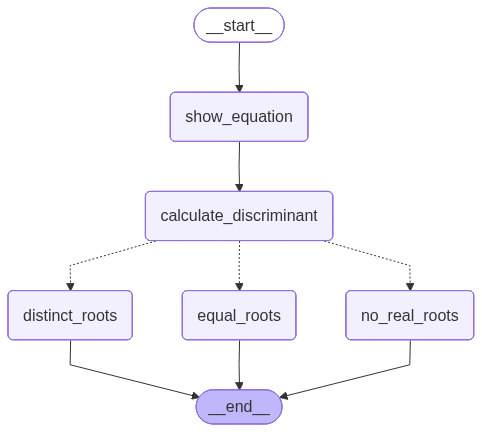

In [21]:
# conditional workflow
# non llm based workflow


# quadratic equation type of roots


from typing import TypedDict,Literal
from langgraph.graph import StateGraph, START, END
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation: str
    discriminant : float
    result: str

def show_equation(state:QuadState):
    eq = f'{state["a"]}x^2 + ({state["b"]})x + {state["c"]}'
    return {"equation":eq}
def calculate_discriminant(state:QuadState):
    disc = state["b"]**2 - (4*state["a"]*state["c"])
    return {"discriminant":disc}
def distinct_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def equal_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

def check_condition(state: QuadState) -> Literal["distinct_roots", "equal_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "distinct_roots"
    elif state['discriminant'] == 0:
        return "equal_roots"
    else:
        return "no_real_roots"

# langgraph orchestration
graph = StateGraph(QuadState)

# nodes 
graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("no_real_roots",no_real_roots)
graph.add_node("distinct_roots",distinct_roots)
graph.add_node("equal_roots",equal_roots)

# edges
graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant",check_condition)
graph.add_edge("distinct_roots",END)
graph.add_edge("equal_roots",END)
graph.add_edge("no_real_roots",END)

app=graph.compile()
app

In [29]:
initial_state = {"a":1,"b":-4,"c":4}
app.invoke(initial_state)

{'a': 1,
 'b': -4,
 'c': 4,
 'equation': '1x^2 + (-4)x + 4',
 'discriminant': 0,
 'result': 'Only repeating root is 2.0'}

In [14]:
# LLM Based Review handling. using conditional edges


from typing import TypedDict,Literal
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os


load_dotenv()
groq_api_key = os.environ.get("GROQ_API")

model = ChatGroq(model="llama-3.1-8b-instant",api_key=groq_api_key,max_tokens=1000)

class SentimentSchema(BaseModel):
    sentiment: Literal["Positive","Negative"]=Field(description="sentiment of the review.")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

struct_model  = model.with_structured_output(SentimentSchema)
struct_model2 = model.with_structured_output(DiagnosisSchema)


class ReviewState(TypedDict):
    review :str
    sentiment : Literal["positive","negative"]
    diagnosis:dict
    response:str

def find_sentiment(state: ReviewState):
    prompt = f"You are a sentiment analyser and find the sentiment of the  given review \n Review: {state['review']}"
    senti = struct_model.invoke(prompt).sentiment 
    return {"sentiment":senti.lower()}

def check_sentiment(state:ReviewState)-> Literal["positive_response","run_diagnosis"]:
    if state["sentiment"]== "positive":
        return "postive_response"
    else :
        return "run_diagnosis"
    
def postive_response(state:ReviewState):
    prompt = f"""Write a warm thankyou message in response to this review:\n\n {state['review']}\n\n
    Also kindly ask the user to leave the feedback on our website."""
    
    response = model.invoke(prompt).content
    return {"response":response}

def run_diagnosis(state:ReviewState):
    prompt = f"""Diagnose the negative review\n\n{state['review']}\n 
                return issue_type,tone and urgency."""
    response = struct_model2.invoke(prompt)
    return {"diagnosis":response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
    
    
    
# langgraph orchestration    

graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', postive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

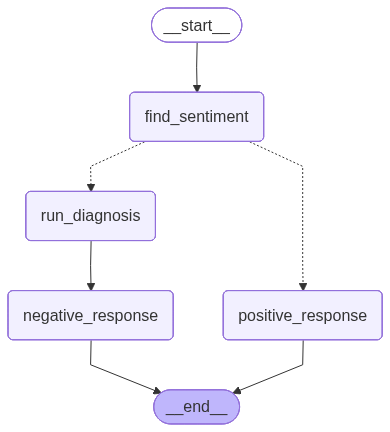

In [15]:
workflow

In [16]:
initial_state = {"review":"The product is really bad "}
workflow.invoke(initial_state)

{'review': 'The product is really bad ',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'UX', 'tone': 'angry', 'urgency': 'high'},
 'response': "Dear [User],\n\nI'm so sorry to hear that you're experiencing a frustrating issue with our platform. I can sense the urgency and frustration in your message, and I appreciate you bringing this to my attention.\n\nI'm here to help you resolve this issue as quickly as possible. To better understand the problem, could you please provide more information about what's not working as expected? Specifically, what were you trying to do when you encountered the issue, and what error messages or behaviors are you seeing?\n\nIn the meantime, I want to assure you that I'm doing my best to expedite the resolution process. I'll work closely with our development team to identify the root cause of the issue and provide a solution.\n\nPlease know that your satisfaction and experience are of the utmost importance to us. I'll keep you updated on the prog